# Introduction

This project shows a simple pricing model for online currency exchange platforms.

This idea comes from my experience working with software for online currency exchange platforms.

Online currency exchange platforms allow users to convert money between different currencies quickly and conveniently. Unlike banks, these platforms usually operate with relatively small profit margins but large transaction volumes.

One of the most important decisions for an exchange platform is how to set its buy and sell prices. These prices are typically based on the market exchange rate, but include a small margin (also known as spread) which represents the platform’s profit.

However, there is an important trade-off:

If the margin is too small, the platform earns very little per transaction.

If the margin is too big, customers may choose competitors and transaction volume will decrease.

The goal of this project is to create a simple mathematical models that demonstrate this relationship and to use Python code to find how different pricing margins affect the expected profit of an online currency exchange platform. In particular, we'll have a short analysis of the Pricing Model, Transaction Volume Model and the Profit Model.

# Pricing Model

Let's start with the basics.

**R** be the market exchange rate

**m** be the margin applied by the exchange platform

The platform sets its prices as:

$$
Buy=R(1−m)
Sell=R(1+m)
$$

The spread is the difference between the sell and buy price:

$$
Spread=Sell−Buy
$$

The platform earns money from this spread for every transaction.

# Transaction Volume Model

In reality, customer demand decreases when prices become less competitive.

To represent this behavior, we use a simple linear model:

$$
Volume=BaseVolume×(1−k × m)
$$

$$
Volume=BaseVolume×(1−k × m)
$$

Where:

**BaseVolume** is the maximum expected transaction volume

**k** represents customer sensitivity to pricing

**m** is the margin

This is a simplified assumption but it allows us to demonstrate the relationship between pricing and demand.

# Profit Model

The expected profit of the platform can be approximated as:

$$
Profit=Volume×Spread
$$

This model shows the main business trade-off:

Larger spreads increase profit per transaction

But higher spreads reduce transaction volume

The optimal margin is therefore somewhere between these extremes.

# Pricing function

In [1]:
def calculate_prices(market_rate, margin):

    buy_price = market_rate * (1 - margin)
    sell_price = market_rate * (1 + margin)
    
    spread = sell_price - buy_price
    
    return buy_price, sell_price, spread

# Transaction Volume Function

In [2]:
def calculate_volume(base_volume, sensitivity, margin):
    
    volume = base_volume * (1 - sensitivity * margin)
    
    if volume < 0:
        volume = 0
        
    return volume

# Profit Calculation

In [3]:
def calculate_profit(market_rate, margin, base_volume, sensitivity):
    
    buy, sell, spread = calculate_prices(market_rate, margin)
    
    volume = calculate_volume(base_volume, sensitivity, margin)
    
    profit = volume * spread
    
    return profit

# Simulation Parameters

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 45.3 MB/s  0:00:00


# Simulation

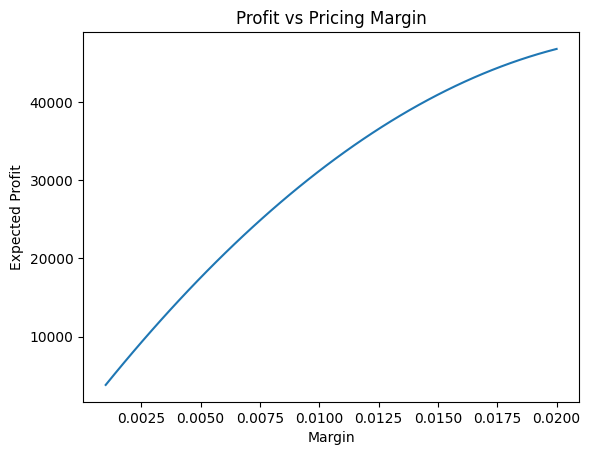

In [8]:
!pip install numpy
!pip install matplotlib
import numpy as np
import matplotlib.pyplot as plt

# Simulation Parameters
market_rate = 1.95

base_volume = 1_000_000

sensitivity = 20

margins = np.linspace(0.001, 0.02, 50)

def calculate_prices(market_rate, margin):

    buy_price = market_rate * (1 - margin)
    sell_price = market_rate * (1 + margin)
    
    spread = sell_price - buy_price
    
    return buy_price, sell_price, spread
    
def calculate_volume(base_volume, sensitivity, margin):
    
    volume = base_volume * (1 - sensitivity * margin)
    
    if volume < 0:
        volume = 0
        
    return volume

    
def calculate_profit(market_rate, margin, base_volume, sensitivity):
    
    buy, sell, spread = calculate_prices(market_rate, margin)
    
    volume = calculate_volume(base_volume, sensitivity, margin)
    
    profit = volume * spread
    
    return profit

# Simulation
profits = []

for m in margins:
    
    profit = calculate_profit(
        market_rate,
        m,
        base_volume,
        sensitivity
    )
    
    profits.append(profit)

# Plot Results
plt.figure()

plt.plot(margins, profits)

plt.xlabel("Margin")
plt.ylabel("Expected Profit")

plt.title("Profit vs Pricing Margin")

plt.show()    

# Results and Interpretation

From the graph we can observe how profit changes when the pricing margin increases.
At very small margins the profit is relatively low because the spread between buy and sell prices is small. As the margin increases, the spread becomes larger and profit increases.
However, after a certain point, profit begins to decrease. This happens because the higher margin reduces transaction volume significantly.
This illustrates the key trade-off faced by online currency exchange platforms when determining their pricing strategy.

# Limitations

This model is intentionally simplified and does not include several real-world factors such as:
* market volatility
* competition from other platforms
* transaction costs
* hedging strategies
* multiple currency pairs
Despite these simplifications, the model provides a useful demonstration of the relationship between pricing margins, customer demand, and profitability.

# Conclusion

In this project we developed a simple mathematical model to study pricing decisions in online currency exchange platforms.
Using basic formulas and Python simulations, we demonstrated how profit depends on the balance between transaction margins and customer demand.
The results show that there is an optimal range of margins where profitability is maximized. Margins that are too small reduce profit per transaction, while margins that are too large discourage customers and decrease transaction volume.
Although simplified, this model illustrates how mathematical thinking and basic programming can help analyze real business problems in financial technology systems.